In [100]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first 5 rows
print("Dataset loaded successfully!\n")
print(df.head())

# Display dataset shape
print("\nShape of the dataset:")
print(df.shape)

# Display information about the dataset
print("\nDataset Information:")
df.info()

Dataset loaded successfully!

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Stream

In [101]:
# Display column names
print("Columns in the dataset:\n")
print(df.columns)

# Display data types
print("\nData Types:\n")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:\n")
print(df.describe())

Columns in the dataset:

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data Types:

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                  

In [102]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [103]:
# Remove customerID column
df = df.drop("customerID", axis=1)

print(df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [104]:
# Check missing values
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [105]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print(df["TotalCharges"].isnull().sum())

0


In [106]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

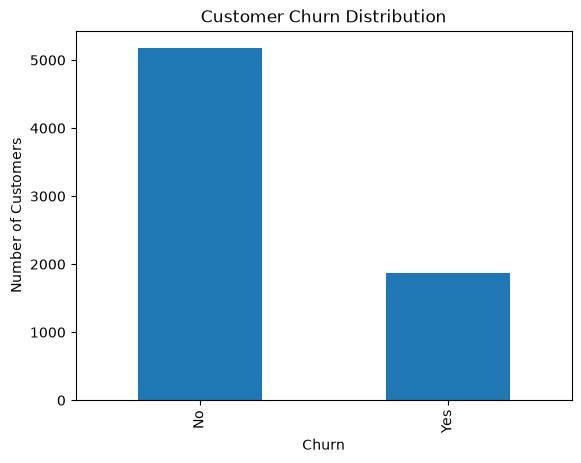

In [107]:
import matplotlib.pyplot as plt

# Churn distribution
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

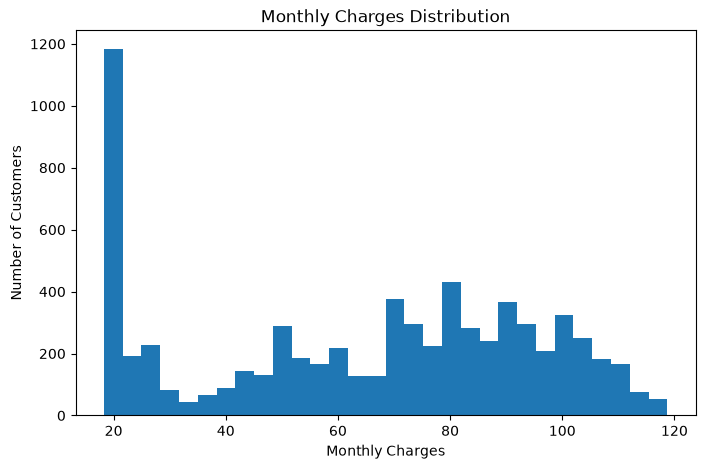

In [108]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

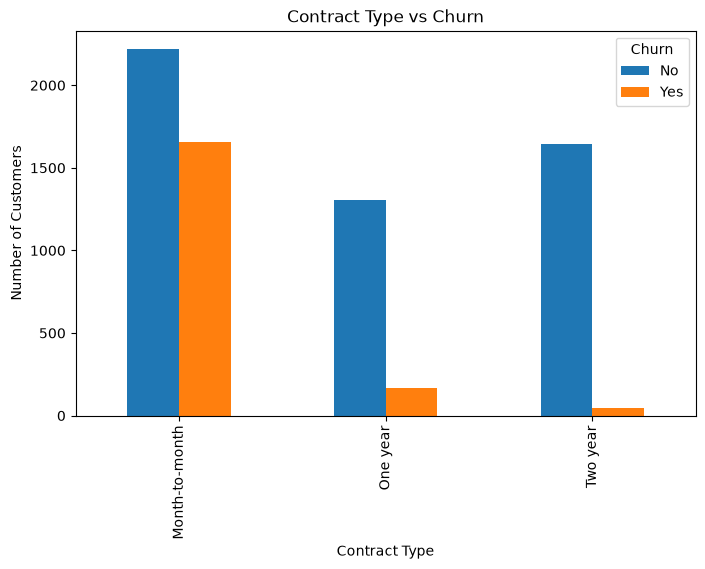

In [109]:
import pandas as pd

contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn.plot(kind="bar", figsize=(8,5))

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

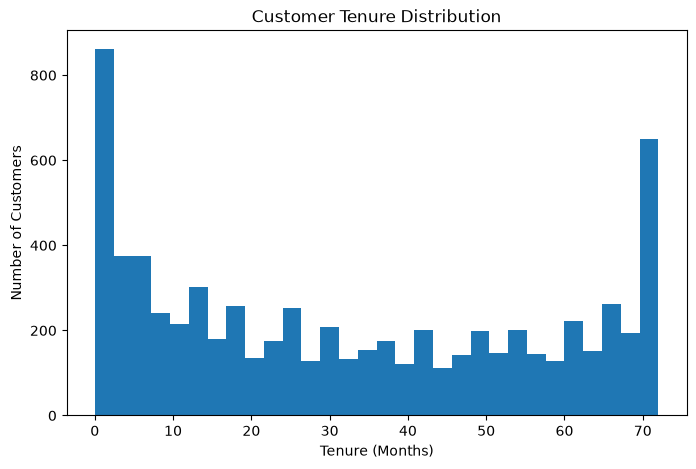

In [110]:
plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=30)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [111]:
# Create a copy of the dataset
df_heatmap = df.copy()

# Convert categorical columns to numeric codes
for column in df_heatmap.select_dtypes(include="object").columns:
    df_heatmap[column] = df_heatmap[column].astype("category").cat.codes

C:\Users\megha\AppData\Local\Temp\ipykernel_23700\12103134.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_heatmap.select_dtypes(include="object").columns:


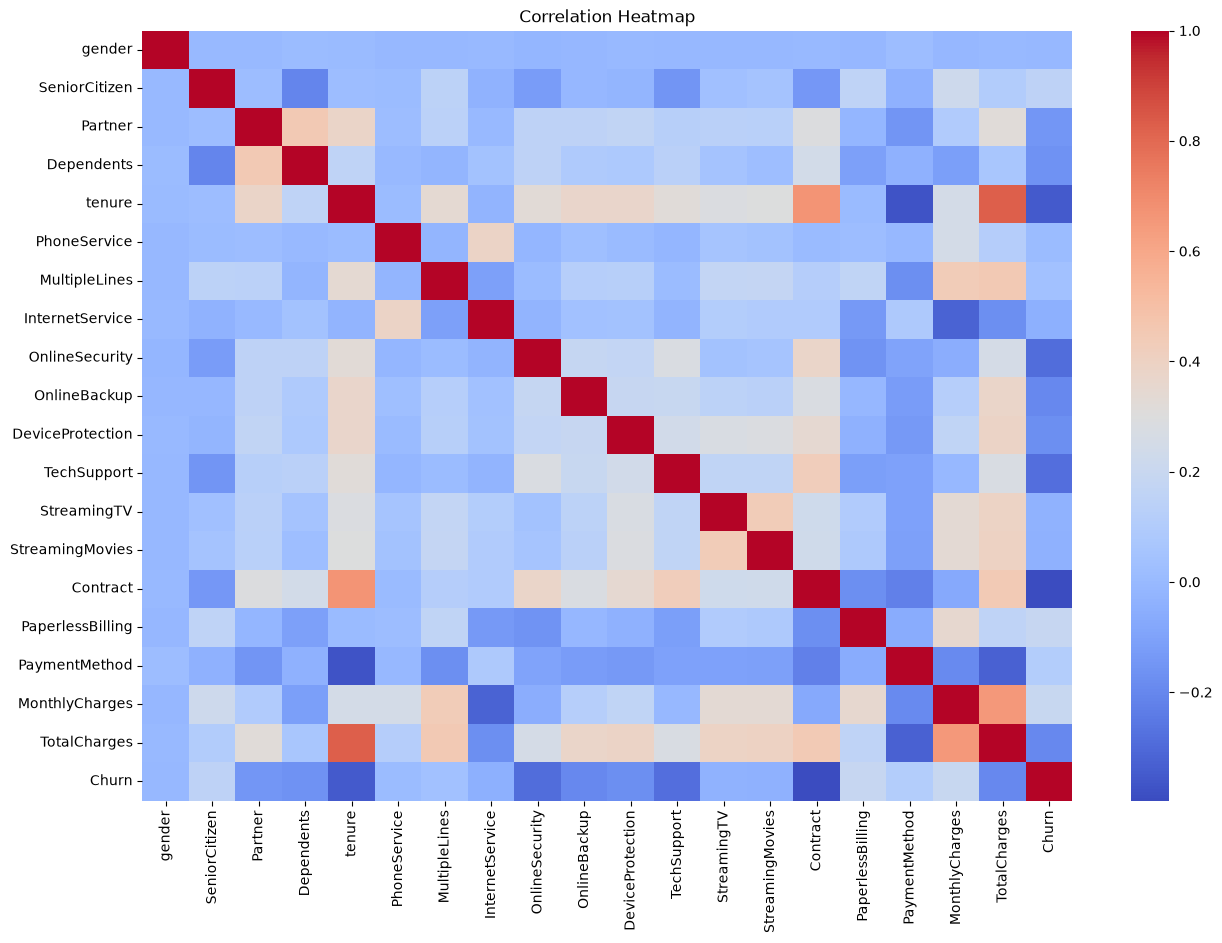

In [112]:
import seaborn as sns

plt.figure(figsize=(15,10))

sns.heatmap(df_heatmap.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [113]:
# Convert Churn to numeric
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [114]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())
print(df_encoded.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

In [115]:
# Features (X) and Target (y)
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 30)
Target shape: (7043,)


In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [117]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7097232079489


In [118]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1036
           1       0.45      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409


Confusion Matrix:

[[831 205]
 [204 169]]


In [119]:
from sklearn.ensemble import GradientBoostingClassifier

# Create the model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Accuracy
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8090844570617459


In [120]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_gb))

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:

[[937  99]
 [170 203]]


In [121]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.81405252 0.80766501 0.79134138 0.8125     0.8046875 ]
Average Accuracy: 0.806049281405252


In [122]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
Best Cross Validation Score: 0.8017394391196309


In [123]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred_best))

Final Accuracy: 0.8119233498935415


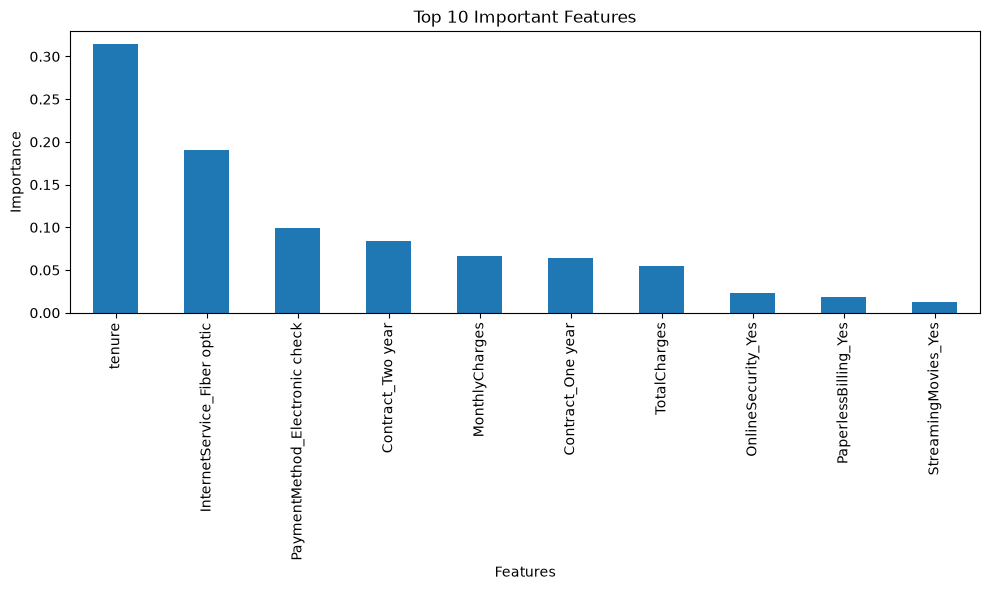

In [124]:
import matplotlib.pyplot as plt
import pandas as pd

importance = best_model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
print("Decision Tree Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Gradient Boosting Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Optimized Model Accuracy :", accuracy_score(y_test, y_pred_best))

Decision Tree Accuracy : 0.7097232079489
Gradient Boosting Accuracy : 0.8090844570617459
Optimized Model Accuracy : 0.8119233498935415
